# **Step3. 속성 기반 감정 분류**

**미션 : 리뷰 안에 담긴 11가지 속성 감성 분석하기(Aspect-Based Sentiment Analysis)**
1) 목표 : 속성 기반 감성 분석을 통해, 리뷰 내용을 속성에 따라 긍, 부정
으로 분류하는 모델 생성
2) 절차① : “[ASPECT] 속성 [SEP] 문장”
    * 데이터 전처리 : 데이터셋 구성, 토크나이즈
    * 스페셜 토큰 추가 + 모델의 임베딩 층 resizing
    * 파인튜닝 및 모델 평가
3) 절차② : “Aspect : 문장”
    * 데이터 전처리 : 데이터셋 구성, 토크나이즈
    * 파인튜닝 및 모델 평가
4) 성능 비교 : “Aspect : 문장”
    * 모델 별 : klue/bert-base, klue/RoBERTa-base
    * 전처리 별 : Case①, Case②
    * Macro Recall, Macro Precision, Macro F1-Score 비교

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import torch

from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### (2) 데이터 로딩
* data.csv 파일 로딩

In [2]:
path = './data/'
df = pd.read_csv(path + 'data.csv')
df.head(1)

,text,aspect,label
0,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,포장,1


* 전제 데이터 중 10,000건만 샘플링
    * 학습 속도 고려

In [3]:
df_10k = df[:10000]
df_10k.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10000 non-null  object
 1   aspect  10000 non-null  object
 2   label   10000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 234.5+ KB


### (3) GPU 설정
* GPU 사용을 위한 설정

In [4]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.방식① : [ASPECT] 속성 [SEP] 문장

* 두가지 모델에 대해서 튜닝을 시도해봅시다.
    * model_name1 = "klue/bert-base"
    * model_name2 = "klue/roberta-base"

### (1) 데이터 준비
* 데이터셋 분할 및 텐서 데이터셋 변환
* 토크나이징 함수 안에서,
    * "[ASPECT] 속성 [SEP] 문장" 형태로 수정
    * 토크나이징

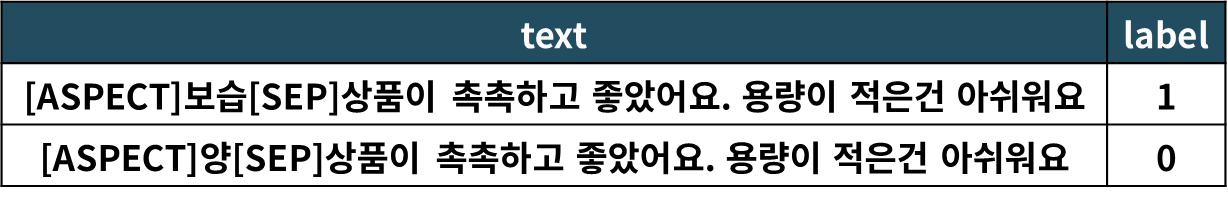

#### 1) 데이터셋 분할 및 텐서 데이터셋 변환

In [8]:
aspects = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']
df_10k.head(1)

,text,aspect,label
0,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,포장,1


In [9]:
# train, val 데이터 분할
train, val = train_test_split(df_10k, test_size=0.2, random_state=42)

In [10]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train) 
val_ts = Dataset.from_pandas(val)

In [11]:
train_ts[:1]

{'text': ['향도 무난하고 손에 발라서 머리에 적당량을 바르면 하루 종일 엉킴없이 머리카락이 찰랑거립니다. 많이 바르면 기름져 보여서 자신의 머리길이에 맞게 발라야 기름지지 않을 것 같아요.'],
 'aspect': ['기타'],
 'label': [1],
 '__index_level_0__': [9254]}

#### 2) 토크나이징
* "[ASPECT] 속성 [SEP] 문장" 형태로 수정
* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

* 토크나이저 준비 : 두 모델에 대한 토크나이저 로딩

In [12]:
model_name1 = "klue/bert-base"
tokenizer1 = AutoTokenizer.from_pretrained(model_name1)

model_name2 = "klue/roberta-base"
tokenizer2 = AutoTokenizer.from_pretrained(model_name2)

In [13]:
display(tokenizer1.special_tokens_map)
display(tokenizer2.special_tokens_map)

{'unk_token': '[UNK]',
 'sep_token': '[SEP]',
 'pad_token': '[PAD]',
 'cls_token': '[CLS]',
 'mask_token': '[MASK]'}

{'bos_token': '[CLS]',
 'eos_token': '[SEP]',
 'unk_token': '[UNK]',
 'sep_token': '[SEP]',
 'pad_token': '[PAD]',
 'cls_token': '[CLS]',
 'mask_token': '[MASK]'}

* 사용자 정의 스페셜 토큰 등록하기

In [14]:
# 사용자 정의 스페셜 토큰 목록
special_tokens_dict = {'additional_special_tokens': ["[ASPECT]"]}

# 토크나이저에 추가
tokenizer1.add_special_tokens(special_tokens_dict)
display(tokenizer1.special_tokens_map)

tokenizer2.add_special_tokens(special_tokens_dict)
display(tokenizer2.special_tokens_map)

{'unk_token': '[UNK]',
 'sep_token': '[SEP]',
 'pad_token': '[PAD]',
 'cls_token': '[CLS]',
 'mask_token': '[MASK]',
 'additional_special_tokens': ['[ASPECT]']}

{'bos_token': '[CLS]',
 'eos_token': '[SEP]',
 'unk_token': '[UNK]',
 'sep_token': '[SEP]',
 'pad_token': '[PAD]',
 'cls_token': '[CLS]',
 'mask_token': '[MASK]',
 'additional_special_tokens': ['[ASPECT]']}

* 토크나이징을 포함한 함수 생성 및 적용

In [15]:
# 모델1 전처리 함수
def preprocess_bert(examples):
    # 텍스트 구성: [ASPECT] + aspect + [SEP] + text
    combined_texts = ['[ASPECT]' + a + '[SEP]' + t for a, t in zip(examples['aspect'], examples['text'])]
    tokenized = tokenizer1(
        combined_texts,
        truncation=True,
        padding='max_length',
        max_length=128
    )
    tokenized['text'] = combined_texts
    tokenized['label'] = examples['label']
    return tokenized


# 모델1 전처리 적용
tokenized_bert_train = train_ts.map(preprocess_bert, batched=True, remove_columns=['aspect'])
tokenized_bert_val = val_ts.map(preprocess_bert, batched=True, remove_columns=['aspect'])


# 모델2 전처리 함수
def preprocess_roberta(examples):
    # 텍스트 구성: [ASPECT] + aspect + [SEP] + text
    combined_texts = ['[ASPECT]' + a + '[SEP]' + t for a, t in zip(examples['aspect'], examples['text'])]
    tokenized = tokenizer2(
        combined_texts,
        truncation=True,
        padding='max_length',
        max_length=128
    )
    tokenized['text'] = combined_texts
    tokenized['label'] = examples['label']
    return tokenized

# 모델2 전처리 적용
tokenized_roberta_train = train_ts.map(preprocess_roberta, batched=True, remove_columns=['aspect'])
tokenized_roberta_val = val_ts.map(preprocess_roberta, batched=True, remove_columns=['aspect'])

Map: 100%|██████████| 2000/2000 [00:00<00:00, 11636.43 examples/s]


In [16]:
display(tokenized_bert_train['text'][1])
display(tokenized_bert_train.column_names)
display(tokenized_roberta_train['text'][1])
display(tokenized_roberta_train.column_names)

'[ASPECT]외형[SEP]사용해보니 손에 묻지 않고 간편하게 새치커버 되네요. 방송에서 보듯 자연스럽게 부풀리기는 손재주가 없어서인지 잘 안되네요.'

['text',
 'label',
 '__index_level_0__',
 'input_ids',
 'token_type_ids',
 'attention_mask']

'[ASPECT]외형[SEP]사용해보니 손에 묻지 않고 간편하게 새치커버 되네요. 방송에서 보듯 자연스럽게 부풀리기는 손재주가 없어서인지 잘 안되네요.'

['text',
 'label',
 '__index_level_0__',
 'input_ids',
 'token_type_ids',
 'attention_mask']

### (2) Fine-Tuning

#### 1) 사전학습 모델 준비
* 모델 로드한 후
* 반드시 `모델.resize_token_embeddings(len(tokenizer))`

In [17]:
# 모델1
n = 2 # 이진분류
model1 = AutoModelForSequenceClassification.from_pretrained(model_name1, num_labels=n)
model1.resize_token_embeddings(len(tokenizer1))

# 모델2
model2 = AutoModelForSequenceClassification.from_pretrained(model_name2, num_labels=n)
model2.resize_token_embeddings(len(tokenizer2))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(32001, 768, padding_idx=1)

#### 2) 학습 설정

* TrainingArguments 설정
    * 두 모델에 공통으로 하나만 설정해도 됨

In [18]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    weight_decay=0.02,
    load_best_model_at_end=True,         
    metric_for_best_model="eval_loss",   
    greater_is_better=False,             
    logging_dir="./logs",
    logging_steps=10,
    report_to=None,
    fp16=True
)

* Trainer 설정
    * 두 모델 각각 설정

In [19]:
# Trainer1 설정
trainer1 = Trainer(
    model=model1,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = tokenized_bert_train,
    eval_dataset = tokenized_bert_val,
    tokenizer = tokenizer1,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

# Trainer2 설정
trainer2 = Trainer(
    model=model2,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = tokenized_roberta_train,
    eval_dataset = tokenized_roberta_val,
    tokenizer = tokenizer2,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

C:\Users\USER\AppData\Local\Temp\ipykernel_9220\4241713487.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer1 = Trainer(
C:\Users\USER\AppData\Local\Temp\ipykernel_9220\4241713487.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer2 = Trainer(


#### 3) 학습

In [20]:
trainer1.train()

Epoch,Training Loss,Validation Loss
1,0.293000,0.256083
2,0.221300,0.221339
3,0.167100,0.235465
4,0.169500,0.247338
5,0.112600,0.270049


TrainOutput(global_step=625, training_loss=0.1995550922393799, metrics={'train_runtime': 145.7256, 'train_samples_per_second': 274.488, 'train_steps_per_second': 4.289, 'total_flos': 2631110553600000.0, 'train_loss': 0.1995550922393799, 'epoch': 5.0})

In [21]:
trainer2.train()

Epoch,Training Loss,Validation Loss
1,0.308400,0.250183
2,0.213400,0.219975
3,0.175800,0.216440
4,0.151400,0.223234
5,0.105400,0.263295


TrainOutput(global_step=625, training_loss=0.19720621571540833, metrics={'train_runtime': 142.6294, 'train_samples_per_second': 280.447, 'train_steps_per_second': 4.382, 'total_flos': 2631110553600000.0, 'train_loss': 0.19720621571540833, 'epoch': 5.0})

#### 4) 모델 검증평가

* 예측

In [22]:
raw_pred1 = trainer1.predict(tokenized_bert_val)
raw_pred2 = trainer2.predict(tokenized_roberta_val)

In [23]:
preds1 = raw_pred1.predictions.argmax(axis=1)
labels1 = raw_pred1.label_ids

In [24]:
preds2 = raw_pred2.predictions.argmax(axis=1)
labels2 = raw_pred2.label_ids

* 평가 : model1

In [25]:
acc1 = accuracy_score(labels1, preds1)
print("Accuracy:", acc1)
print("\nClassification Report:")
print(classification_report(labels1, preds1, digits=4))

Accuracy: 0.9335

Classification Report:
              precision    recall  f1-score   support

           0     0.8893    0.8577    0.8732       534
           1     0.9488    0.9611    0.9549      1466

    accuracy                         0.9335      2000
   macro avg     0.9191    0.9094    0.9141      2000
weighted avg     0.9329    0.9335    0.9331      2000



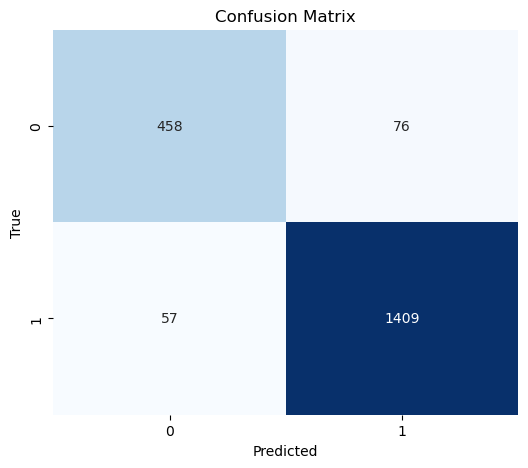

In [26]:
cm1 = confusion_matrix(labels1, preds1)

plt.figure(figsize=(6,5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [27]:
val_df1 = val_ts.to_pandas()
val_df1["pred"] = preds1

In [28]:
val_df1[["text", "aspect", "label", "pred"]].sample(5)

,text,aspect,label,pred
1860,행사할 때 저렴하게 사서 좋습니다. 비누로 대충 쓰던 것보다 피부가 덜 건조해지네요.,보습,1,1
353,바르고 비닐씌우고 양말신으니 적은양으로도 잘 발려요. 무엇보다 향이 너무 좋네요.,밀착,1,1
1333,사은품으로 온 파우더 매트와 틴트는 맘에 드네요. 유분기는 좀 있지만 촉촉하고 부드...,보습,0,0
905,제형 입자가 고와서인지 색상이 화사하고 바름도 좋습니다 바르고나서는 묻어남도 없구요...,기타,1,1
1289,1+1구성이라 구매해 봤습니다. 샤워 후 물기 마르기 전에 발라보니 건성 피부라 촉...,품질,1,0


* 평가 : model2

In [29]:
acc2 = accuracy_score(labels2, preds2)
print("Accuracy:", acc2)
print("\nClassification Report:")
print(classification_report(labels2, preds2, digits=4))

Accuracy: 0.941

Classification Report:
              precision    recall  f1-score   support

           0     0.9298    0.8427    0.8841       534
           1     0.9446    0.9768    0.9604      1466

    accuracy                         0.9410      2000
   macro avg     0.9372    0.9098    0.9223      2000
weighted avg     0.9406    0.9410    0.9400      2000



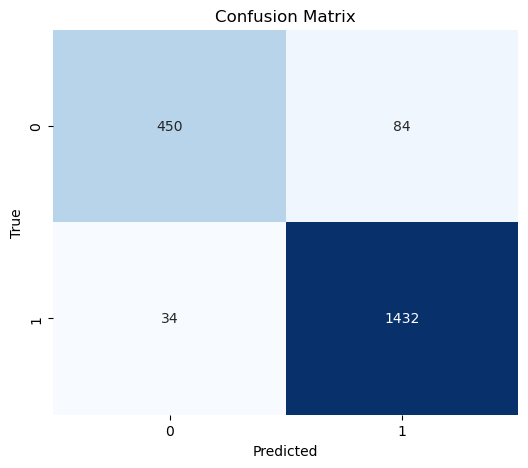

In [30]:
cm2 = confusion_matrix(labels2, preds2)

plt.figure(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [31]:
val_df2 = val_ts.to_pandas()
val_df2["pred"] = preds2

In [32]:
val_df2[["text", "aspect", "label", "pred"]].sample(5)

,text,aspect,label,pred
1829,딸아이가 추천해준 제품 리뷰해보려고 해요 가격도 효과도 아주 착한 제품입니다. 본인...,밀착,1,1
409,리리코스 기초는 처음 사용해보는데 너무 만족스러워요^^ 가을이라 건조해지는 것 때문...,보습,1,1
1513,포인트로 할인 받아 구매했어요 요즘 많이 쓰더라고요 저렴하게 살 기회있어 저도 함 ...,포장,0,0
863,아들이 필요하다고 사달라고 하네요. 순하고 거품이 쫀쫀해서 좋은데 좀 더 풍부한 거...,피부,1,1
1867,염색이 부자연스러운 느낌이 들어서 별로입니다. 색도 잘 빠지네요.,기타,0,0


## 3.방식② : 속성 : 문장

* 두가지 모델에 대해서 튜닝을 시도해봅시다.
    * model_name1 = "klue/bert-base"
    * model_name2 = "klue/roberta-base"

### (1) 데이터 준비
* 데이터셋 분할 및 텐서 데이터셋 변환
* 토크나이징 함수 안에서,
    * "ASPECT : 문장" 형태로 수정
    * 토크나이징

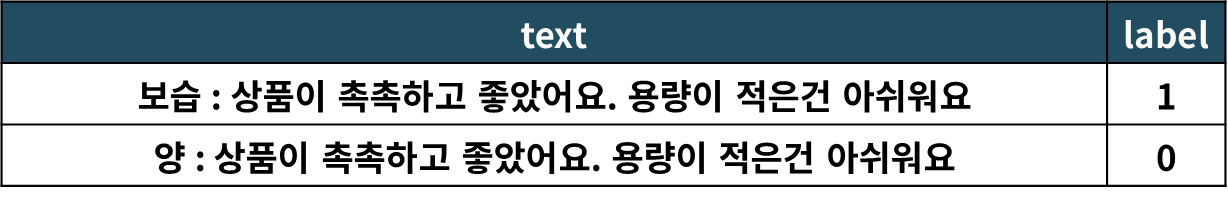

#### 1) 데이터셋 분할 및 텐서 데이터셋 변환

In [5]:
aspects = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']
df_10k[:1]

,text,aspect,label
0,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,포장,1


In [6]:
# train, val 데이터 분할
train, val = train_test_split(df_10k, test_size=0.2, random_state=42)

In [7]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train) 
val_ts = Dataset.from_pandas(val)

In [8]:
train_ts[:1]

{'text': ['향도 무난하고 손에 발라서 머리에 적당량을 바르면 하루 종일 엉킴없이 머리카락이 찰랑거립니다. 많이 바르면 기름져 보여서 자신의 머리길이에 맞게 발라야 기름지지 않을 것 같아요.'],
 'aspect': ['기타'],
 'label': [1],
 '__index_level_0__': [9254]}

#### 2) 토크나이징
* "ASPECT : 문장" 형태로 수정
* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

* 토크나이저 준비 : 두 모델에 대한 토크나이저 로딩

In [9]:
model_name1 = "klue/bert-base"
tokenizer1 = AutoTokenizer.from_pretrained(model_name1)

model_name2 = "klue/roberta-base"
tokenizer2 = AutoTokenizer.from_pretrained(model_name2)

In [10]:
display(tokenizer1.special_tokens_map)
display(tokenizer2.special_tokens_map)

{'unk_token': '[UNK]',
 'sep_token': '[SEP]',
 'pad_token': '[PAD]',
 'cls_token': '[CLS]',
 'mask_token': '[MASK]'}

{'bos_token': '[CLS]',
 'eos_token': '[SEP]',
 'unk_token': '[UNK]',
 'sep_token': '[SEP]',
 'pad_token': '[PAD]',
 'cls_token': '[CLS]',
 'mask_token': '[MASK]'}

* 토크나이징을 포함한 함수 생성 및 적용

In [13]:
# 모델3 전처리 함수
def preprocess_bert(examples):
    # 텍스트 구성: aspect + ':' + text
    combined_texts = [a + ':' + t for a, t in zip(examples['aspect'], examples['text'])]
    tokenized = tokenizer1(
        combined_texts,
        truncation=True,
        padding='max_length',
        max_length=128
    )
    tokenized['text'] = combined_texts
    tokenized['label'] = examples['label']
    return tokenized


# 모델3 전처리 적용
tokenized_bert_train = train_ts.map(preprocess_bert, batched=True, remove_columns=['aspect'])
tokenized_bert_val = val_ts.map(preprocess_bert, batched=True, remove_columns=['aspect'])

# 모델2 전처리 함수
def preprocess_roberta(examples):
    # 텍스트 구성: aspect + ':' + text
    combined_texts = [a + ':' + t for a, t in zip(examples['aspect'], examples['text'])]
    tokenized = tokenizer2(
        combined_texts,
        truncation=True,
        padding='max_length',
        max_length=128
    )
    tokenized['text'] = combined_texts
    tokenized['label'] = examples['label']
    return tokenized


# 모델2 전처리 적용
tokenized_roberta_train = train_ts.map(preprocess_roberta, batched=True, remove_columns=['aspect'])
tokenized_roberta_val = val_ts.map(preprocess_roberta, batched=True, remove_columns=['aspect'])

Map: 100%|██████████| 2000/2000 [00:00<00:00, 12939.83 examples/s]


In [14]:
display(tokenized_bert_train['text'][1])
display(tokenized_bert_train.column_names)
display(tokenized_roberta_train['text'][1])
display(tokenized_roberta_train.column_names)

'외형:사용해보니 손에 묻지 않고 간편하게 새치커버 되네요. 방송에서 보듯 자연스럽게 부풀리기는 손재주가 없어서인지 잘 안되네요.'

['text',
 'label',
 '__index_level_0__',
 'input_ids',
 'token_type_ids',
 'attention_mask']

'외형:사용해보니 손에 묻지 않고 간편하게 새치커버 되네요. 방송에서 보듯 자연스럽게 부풀리기는 손재주가 없어서인지 잘 안되네요.'

['text',
 'label',
 '__index_level_0__',
 'input_ids',
 'token_type_ids',
 'attention_mask']

### (2) Fine-Tuning

#### 1) 사전학습 모델 준비

In [15]:
# 모델1
n = 2 # 이진분류
model1 = AutoModelForSequenceClassification.from_pretrained(model_name1, num_labels=n)
model1.resize_token_embeddings(len(tokenizer1))

# 모델2
model2 = AutoModelForSequenceClassification.from_pretrained(model_name2, num_labels=n)
model2.resize_token_embeddings(len(tokenizer2))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(32000, 768, padding_idx=1)

#### 2) 학습 설정

* TrainingArguments 설정
    * 두 모델에 공통으로 하나만 설정해도 됨

In [16]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    weight_decay=0.02,
    load_best_model_at_end=True,         
    metric_for_best_model="eval_loss",   
    greater_is_better=False,             
    logging_dir="./logs",
    logging_steps=10,
    report_to=None,
    fp16=True
)

* Trainer 설정
    * 두 모델 각각 설정

In [17]:
# Trainer1 설정
trainer1 = Trainer(
    model=model1,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = tokenized_bert_train,
    eval_dataset = tokenized_bert_val,
    tokenizer = tokenizer1,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

# Trainer2 설정
trainer2 = Trainer(
    model=model2,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = tokenized_roberta_train,
    eval_dataset = tokenized_roberta_val,
    tokenizer = tokenizer2,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

C:\Users\USER\AppData\Local\Temp\ipykernel_7388\4241713487.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer1 = Trainer(
C:\Users\USER\AppData\Local\Temp\ipykernel_7388\4241713487.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer2 = Trainer(


#### 3) 학습

In [18]:
trainer1.train()

Epoch,Training Loss,Validation Loss
1,0.291900,0.258480
2,0.226600,0.232867
3,0.175100,0.227059
4,0.180200,0.251888
5,0.092800,0.266160


TrainOutput(global_step=625, training_loss=0.20975514516830443, metrics={'train_runtime': 144.9599, 'train_samples_per_second': 275.938, 'train_steps_per_second': 4.312, 'total_flos': 2631110553600000.0, 'train_loss': 0.20975514516830443, 'epoch': 5.0})

In [19]:
trainer2.train()

Epoch,Training Loss,Validation Loss
1,0.276300,0.245321
2,0.214300,0.201136
3,0.164100,0.219520
4,0.145100,0.232361
5,0.111600,0.257665


TrainOutput(global_step=625, training_loss=0.18917285742759704, metrics={'train_runtime': 146.2124, 'train_samples_per_second': 273.575, 'train_steps_per_second': 4.275, 'total_flos': 2631110553600000.0, 'train_loss': 0.18917285742759704, 'epoch': 5.0})

#### 4) 모델 검증평가

* 예측

In [24]:
raw_pred1 = trainer1.predict(tokenized_bert_val)
raw_pred2 = trainer2.predict(tokenized_roberta_val)

In [25]:
preds1 = raw_pred1.predictions.argmax(axis=1)
labels1 = raw_pred1.label_ids

preds2 = raw_pred2.predictions.argmax(axis=1)
labels2 = raw_pred2.label_ids

* 평가

Accuracy: 0.931

Classification Report:
              precision    recall  f1-score   support

           0     0.8899    0.8683    0.8789       577
           1     0.9471    0.9564    0.9517      1423

    accuracy                         0.9310      2000
   macro avg     0.9185    0.9124    0.9153      2000
weighted avg     0.9306    0.9310    0.9307      2000



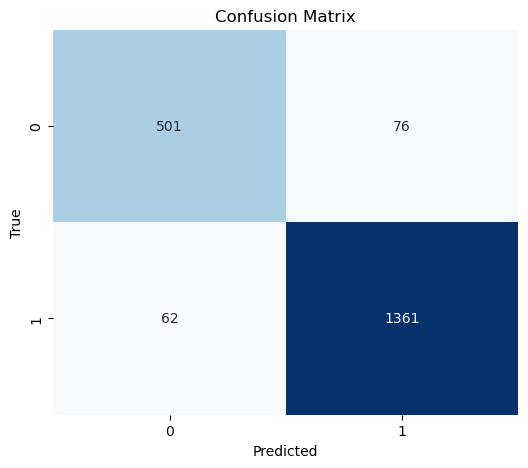

,text,aspect,label,pred
1860,다들 머리 고민 많으시죠? 풍성했던 머리가 시간이 지날 수록 빠지기 시작했어요ㅠㅠ ...,기능,1,0
353,아들들이 제일 많이 찾는 제품이래요~ ㅇㅇㅇ 올인원을 써본 후기 올립니다~ 아들 군...,향,1,1
1333,향 괜찮고 고정력 좋습니다. 분사력도 아주 좋아요. 500ml 라서 양이 많아서 정...,기능,1,1
905,처음 사용하는데 실망했어요. 가격이 만만치 않았지만 엄마랑 함께 사용하려고 구매했어...,기능,0,0
1289,화장기를 유분으로 녹여주는 느낌이예요. 세게 문지르지 않아도 모공까지 클렌징 되는것...,기능,1,1


In [26]:
acc1 = accuracy_score(labels1, preds1)
print("Accuracy:", acc1)
print("\nClassification Report:")
print(classification_report(labels1, preds1, digits=4))

cm1 = confusion_matrix(labels1, preds1)

plt.figure(figsize=(6,5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

val_df1 = val_ts.to_pandas()
val_df1["pred"] = preds1

val_df1[["text", "aspect", "label", "pred"]].sample(5)

Accuracy: 0.935

Classification Report:
              precision    recall  f1-score   support

           0     0.9060    0.8577    0.8812       562
           1     0.9455    0.9652    0.9553      1438

    accuracy                         0.9350      2000
   macro avg     0.9258    0.9114    0.9182      2000
weighted avg     0.9344    0.9350    0.9344      2000



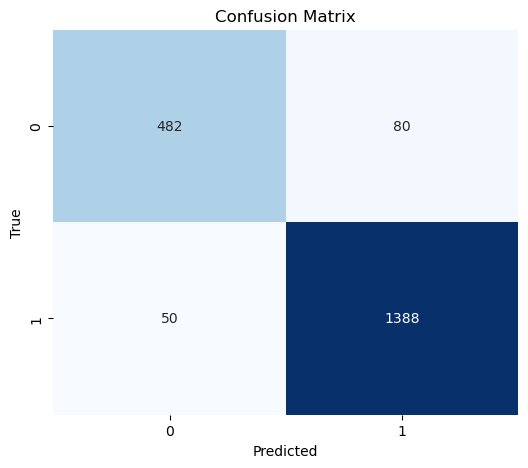

,text,aspect,label,pred
1860,자몽향이 너무 좋아요 사은품 서비스로 신제품 바디워시도 왔는데 촉촉하고 좋네요,품질,1,1
353,요즘 얼굴도 건조하고 입도 건조하고 손도 건조해서 건조 비상 상황입니다. OO OO...,보습,1,1
1333,사용한 지 오래 되지는 않았습니다. 휴대하기 편해서 좋고 생각보다 크기도 작지 않고...,편의성,1,1
905,OOO를 이렇게 저렴하게 득텝하다니 넘 만족스럽습니다. OOO 좋은거야 뭐 말안해도...,가격,1,1
1289,주말주문후 이틀만에 총알배송오자마자 열어보고 깜짝놀랐네요! 케이스완전 취저.... ...,보습,1,1


In [25]:
acc2 = accuracy_score(labels2, preds2)
print("Accuracy:", acc2)
print("\nClassification Report:")
print(classification_report(labels2, preds2, digits=4))

cm2 = confusion_matrix(labels2, preds2)

plt.figure(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

val_df2 = val_ts.to_pandas()
val_df2["pred"] = preds2

val_df2[["text", "aspect", "label", "pred"]].sample(5)

# 모델 성능비교

In [20]:
import os
import numpy as np
import pandas as pd
from scipy.special import softmax, expit
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, average_precision_score

os.makedirs("saved_preds", exist_ok=True)

def logits_to_probs(logits):
    logits = np.asarray(logits)
    if logits.ndim == 2 and logits.shape[1] == 2:
        return softmax(logits, axis=1)[:,1]
    if logits.ndim == 2 and logits.shape[1] == 1:
        return expit(logits[:,0])
    if logits.ndim == 1:
        return expit(logits)
    return softmax(logits, axis=1)[:,-1]

def eval_and_save(trainer, name, outdir="saved_preds", threshold=0.5):
    raw = trainer.predict(getattr(trainer, "eval_dataset"))
    logits = raw.predictions
    labels = raw.label_ids
    probs = logits_to_probs(logits)
    preds = (probs >= threshold).astype(int)

    # metrics
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    try:
        roc_auc = roc_auc_score(labels, probs)
    except:
        roc_auc = np.nan
    try:
        pr_auc = average_precision_score(labels, probs)
    except:
        pr_auc = np.nan

    metrics = {
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': float(roc_auc) if not np.isnan(roc_auc) else None,
        'pr_auc': float(pr_auc) if not np.isnan(pr_auc) else None,
        'n_samples': int(len(labels))
    }

    # 1) save arrays compressed (npz)
    np.savez_compressed(os.path.join(outdir, f"{name}_preds.npz"),
                        probs=probs.astype(np.float32),
                        preds=preds.astype(np.int8),
                        labels=labels.astype(np.int8))

    # 2) save metrics as json/csv line
    metrics_df = pd.DataFrame([{'model': name, **metrics}])
    metrics_df.to_csv(os.path.join(outdir, "metrics_summary.csv"), mode='a', header=not os.path.exists(os.path.join(outdir, "metrics_summary.csv")), index=False)

    # (선택) 3) save full table (parquet) — 디버깅/리뷰용
    df = pd.DataFrame({'prob': probs, 'pred': preds, 'label': labels})
    df.to_parquet(os.path.join(outdir, f"{name}_table.parquet"))

    print(f"Saved {name} -> {outdir}")
    return metrics

# 사용 예:
# trainers = [trainer1, trainer2, trainer3, trainer4]
# names = ['m1','m2','m3','m4']
# for tr, nm in zip(trainers, names):
#     eval_and_save(tr, nm)


In [21]:
# 사용 예:
trainers = [trainer1, trainer2]
names = ['m3','m4']
for tr, nm in zip(trainers, names):
    eval_and_save(tr, nm)

Saved m3 -> saved_preds


Saved m4 -> saved_preds



=== Summary ===
  model  n_samples  accuracy  precision    recall        f1   roc_auc  \
0    m2       2000    0.9235   0.936738  0.973462  0.954747  0.958578   
1    m4       2000    0.9150   0.930556  0.969843  0.949793  0.954431   
2    m1       2000    0.9060   0.920481  0.970446  0.944803  0.943056   
3    m3       2000    0.9145   0.929521  0.970446  0.949543  0.943194   

     pr_auc     brier  
0  0.990637  0.060317  
1  0.989200  0.060237  
2  0.987242  0.067634  
3  0.986691  0.066522  


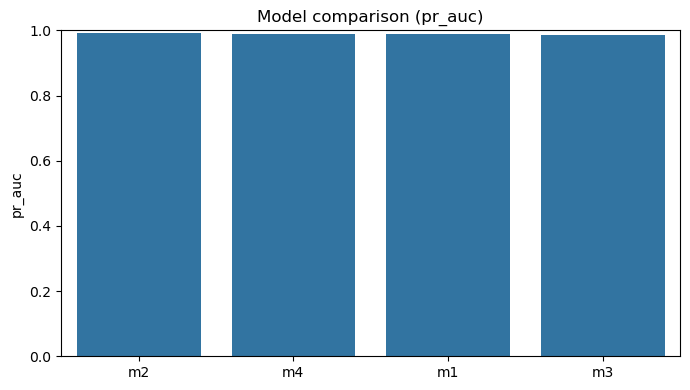

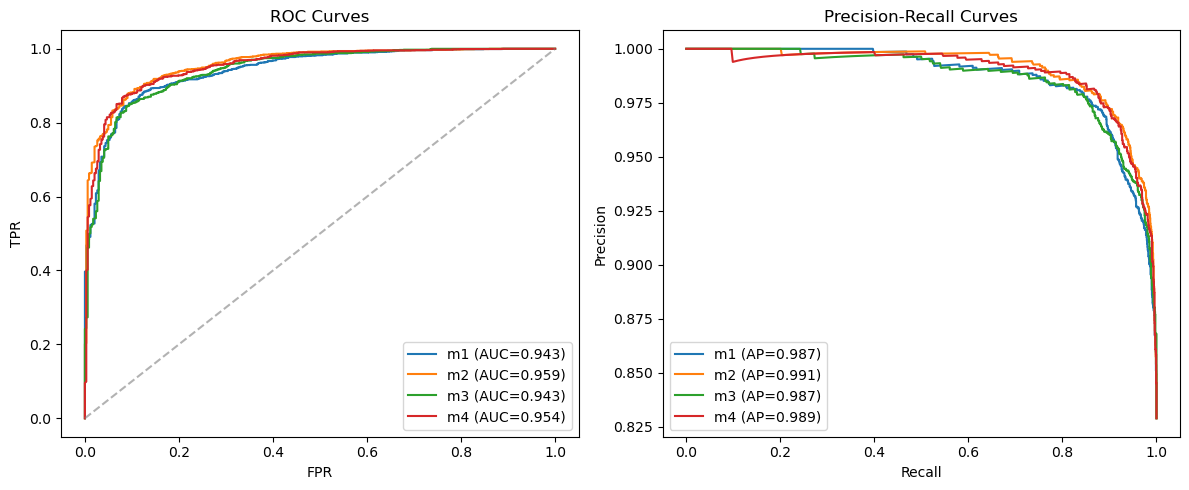

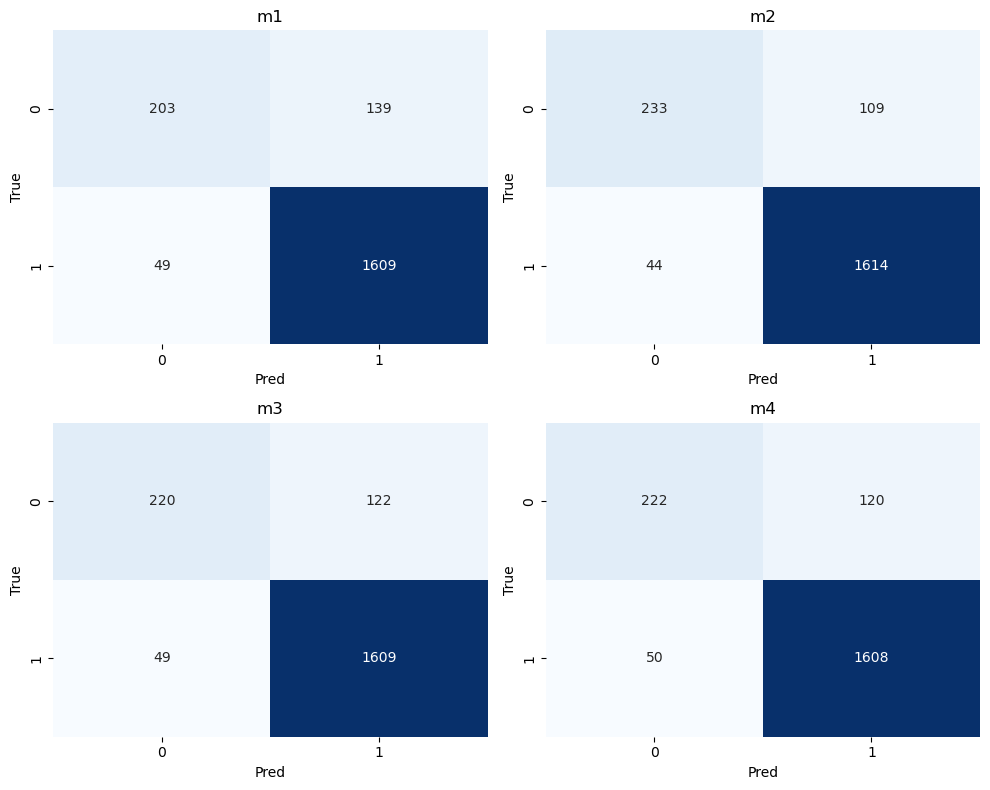

In [ ]:
# saved_preds 시각화 도구
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax, expit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, average_precision_score, confusion_matrix,
    brier_score_loss, roc_curve, precision_recall_curve, auc
)

SAVED_DIR = "data"  # 저장된 폴더
MODELS = ['m1','m2','m3','m4']  # 불러올 모델 이름 리스트

# 유틸: npz 파일에서 probs, preds, labels 불러오기
def load_npz_predictions(model_name, outdir=SAVED_DIR):
    path = os.path.join(outdir, f"{model_name}_preds.npz")
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    arr = np.load(path)
    probs = arr['probs']
    preds = arr['preds']
    labels = arr['labels']
    return probs, preds, labels

# 유틸: metrics 계산
def compute_metrics_from_arrays(probs, preds, labels):
    metrics = {}
    metrics['accuracy'] = float(accuracy_score(labels, preds))
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    metrics['precision'] = float(p)
    metrics['recall'] = float(r)
    metrics['f1'] = float(f1)
    # ROC-AUC / PR-AUC 계산 (single-class 예외 처리)
    try:
        metrics['roc_auc'] = float(roc_auc_score(labels, probs))
    except Exception:
        metrics['roc_auc'] = float('nan')
    try:
        metrics['pr_auc'] = float(average_precision_score(labels, probs))
    except Exception:
        metrics['pr_auc'] = float('nan')
    # brier
    try:
        metrics['brier'] = float(brier_score_loss(labels, probs))
    except Exception:
        metrics['brier'] = float('nan')
    metrics['n_samples'] = int(len(labels))
    return metrics

# 시각화: 요약표 및 막대그래프
def summarize_and_plot(models=MODELS, primary_metric='pr_auc', outdir=SAVED_DIR, show_table=True):
    rows = []
    results = {}
    for m in models:
        probs, preds, labels = load_npz_predictions(m, outdir)
        metrics = compute_metrics_from_arrays(probs, preds, labels)
        rows.append({'model': m, **metrics})
        results[m] = {'probs':probs, 'preds':preds, 'labels':labels, **metrics}
    df = pd.DataFrame(rows).sort_values(by=primary_metric, ascending=False).reset_index(drop=True)

    if show_table:
        print("\n=== Summary ===")
        print(df[['model','n_samples','accuracy','precision','recall','f1','roc_auc','pr_auc','brier']])

    # 막대그래프 (primary metric)
    plt.figure(figsize=(7,4))
    sns.barplot(data=df, x='model', y=primary_metric)
    plt.ylim(0,1)
    plt.title(f"Model comparison ({primary_metric})")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

    return results, df

# 시각화: ROC/PR 곡선
def plot_roc_pr_for_results(results):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    for name, r in results.items():
        labels = r['labels']; probs = r['probs']
        if len(np.unique(labels))==1:
            continue
        fpr, tpr, _ = roc_curve(labels, probs)
        roc_auc = roc_auc_score(labels, probs)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'--', color='gray', alpha=0.6)
    plt.title("ROC Curves"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()

    plt.subplot(1,2,2)
    for name, r in results.items():
        labels = r['labels']; probs = r['probs']
        if len(np.unique(labels))==1:
            continue
        prec, rec, _ = precision_recall_curve(labels, probs)
        ap = average_precision_score(labels, probs)
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    plt.title("Precision-Recall Curves"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend()
    plt.tight_layout()
    plt.show()

# 시각화: 혼동행렬 여러개 한 번에
def plot_confusion_matrices(results):
    names = list(results.keys())
    n = len(names)
    cols = min(2, n)
    rows = (n + cols - 1)//cols
    plt.figure(figsize=(5*cols, 4*rows))
    for i, name in enumerate(names):
        cm = confusion_matrix(results[name]['labels'], results[name]['preds'])
        plt.subplot(rows, cols, i+1)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(name)
        plt.xlabel('Pred'); plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# ========== 실행 예시 ==========
results, summary_df = summarize_and_plot(models=MODELS, primary_metric='pr_auc', outdir=SAVED_DIR)
plot_roc_pr_for_results(results)
plot_confusion_matrices(results)
